## Section 2

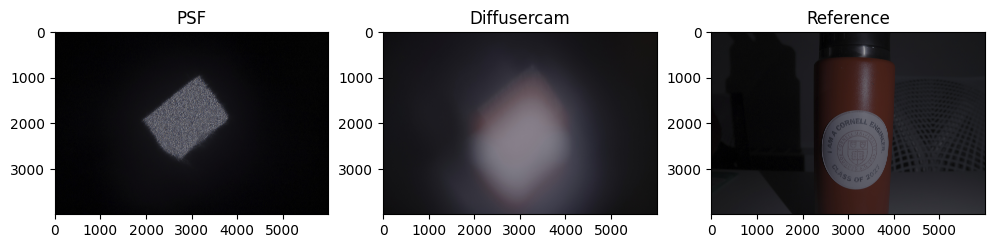

(4000, 6000, 3)


In [29]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

psf = (plt.imread('img/IMG_0154.jpg').astype(np.float64)) / 255.0
dif = (plt.imread('img/IMG_0155.jpg').astype(np.float64)) / 255.0
reference = (plt.imread('img/IMG_0156.jpg').astype(np.float64)) / 255.0
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("PSF")
plt.imshow(psf, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Diffusercam")
plt.imshow(dif, cmap='gray')
plt.subplot(1, 3, 3)
plt.title("Reference")
plt.imshow(reference, cmap='gray')   
plt.show()

print(reference.shape)


[[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00]
  ...
  [9.30525899e-10 9.30525899e-10 9.30525899e-10]
  [9.30525899e-10 9.30525899e-10 9.30525899e-10]
  [9.30525899e-10 9.30525899e-10 9.30525899e-10]]

 [[3.72210360e-09 3.72210360e-09 3.72210360e-09]
  [2.79157770e-09 2.79157770e-09 2.79157770e-09]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00]
  ...
  [3.72210360e-09 3.72210360e-09 3.72210360e-09]
  [3.72210360e-09 3.72210360e-09 3.72210360e-09]
  [3.72210360e-09 3.72210360e-09 3.72210360e-09]]

 [[4.65262949e-09 4.65262949e-09 4.65262949e-09]
  [2.79157770e-09 2.79157770e-09 2.79157770e-09]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00]
  ...
  [4.65262949e-09 4.65262949e-09 4.65262949e-09]
  [3.72210360e-09 3.72210360e-09 3.72210360e-09]
  [3.72210360e-09 3.72210360e-09 3.72210360e-09]]

 ...

 [[0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.0000

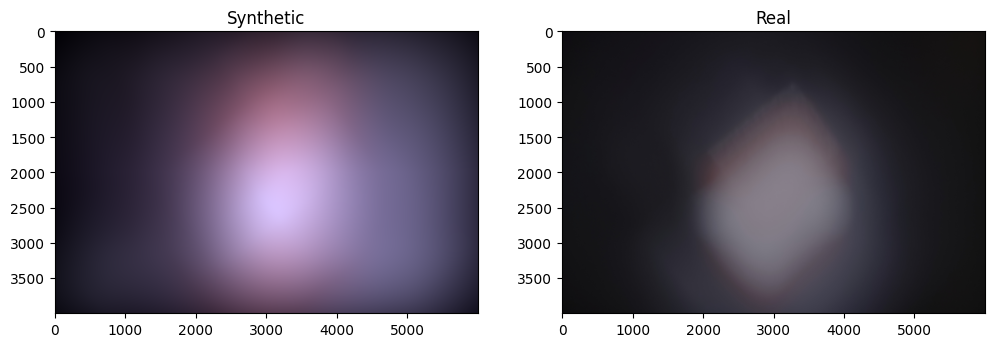

In [30]:
def pad(img):
    return np.pad(img, ((img.shape[0]//2, img.shape[0]//2), (img.shape[1]//2, img.shape[1]//2), (0, 0)), mode="constant")

def crop(img):
    return img[img.shape[0]//4:-img.shape[0]//4, img.shape[1]//4:-img.shape[1]//4]

def forward(x,h):
    x_padded = pad(x)
    h_padded = pad(h)
    X = np.fft.fft2(x_padded, axes=(0, 1))
    H = np.fft.fft2(h_padded, axes=(0, 1))
    Y = X * H
    y_full = np.fft.ifftshift(np.fft.ifft2(Y, axes=(0, 1)), axes=(0, 1))
    y_cropped = crop(y_full)
    return np.abs(y_cropped)

min_val = reference.min()
max_val = reference.max()
reference_norm = (reference - min_val) / (max_val - min_val)
reference_result = forward(reference_norm, psf)

min_val = reference_result.min()
max_val = reference_result.max()
reference_result_display = (reference_result - min_val) / (max_val - min_val)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Synthetic")
plt.imshow(reference_result_display, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Real")
plt.imshow(dif, cmap='gray')

Wiener Deconvolution

In [20]:
def naive_deconv(y, h): 
    y_padded = pad(y)
    h_padded = pad(h)
    
    Y = np.fft.fft2(y_padded, axes=(0, 1))
    H = np.fft.fft2(h_padded, axes=(0, 1))
    
    X = Y / H
    x_full = np.fft.ifftshift(np.fft.ifft2(X, axes=(0, 1)), axes=(0, 1))
    
    return np.real(crop(x_full))
    

In [32]:

def wiener(y, h, tau):
    y_padded = pad(y)
    h_padded = pad(h)

    Y = np.fft.fft2(y_padded, axes=(0, 1))
    H = np.fft.fft2(h_padded, axes=(0, 1))

    H_conj = np.conj(H)
    G = H_conj / (np.abs(H)**2 + tau)

    X_hat = G * Y
    x_full = np.fft.ifftshift(np.fft.ifft2(X_hat, axes=(0,1)), axes=(0,1))

    return np.real(crop(x_full))

In [ ]:

naive_synth = naive_deconv(reference_result, psf)
naive_real = naive_deconv(dif, psf)

def normalize(img):
    return (img - img.min()) / (img.max() - img.min())

naive_synth = normalize(naive_synth)
naive_real = normalize(naive_real)

NameError: name 'naive_synth' is not defined

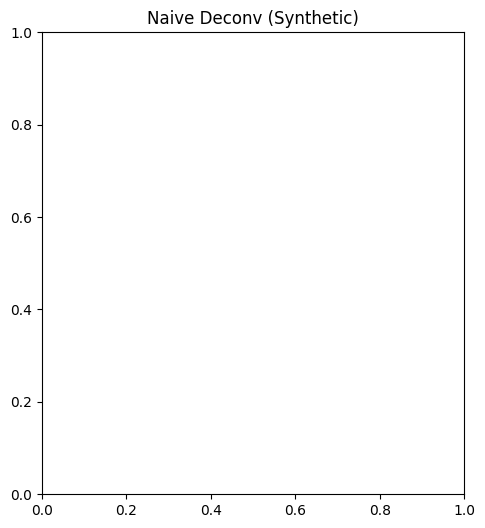

In [19]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Naive Deconv (Synthetic)")
plt.imshow(naive_synth, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Naive Deconv (Real)")
plt.imshow(naive_real, cmap='gray')
plt.axis('off')

plt.show()

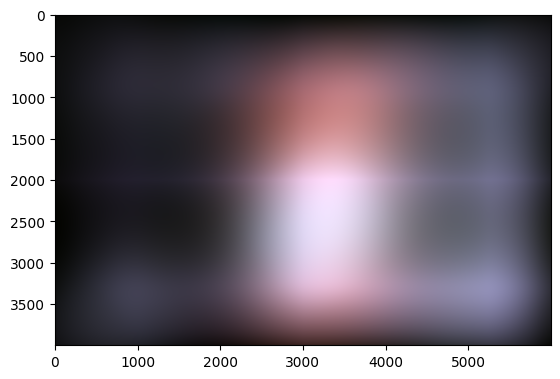

In [ ]:
psf/=psf.sum()
recon = wiener(reference_result_display, psf, 10**-2)
recon = (recon - recon.min()) / (recon.max() - recon.min())

plt.imshow(recon, cmap='gray')
plt.show()

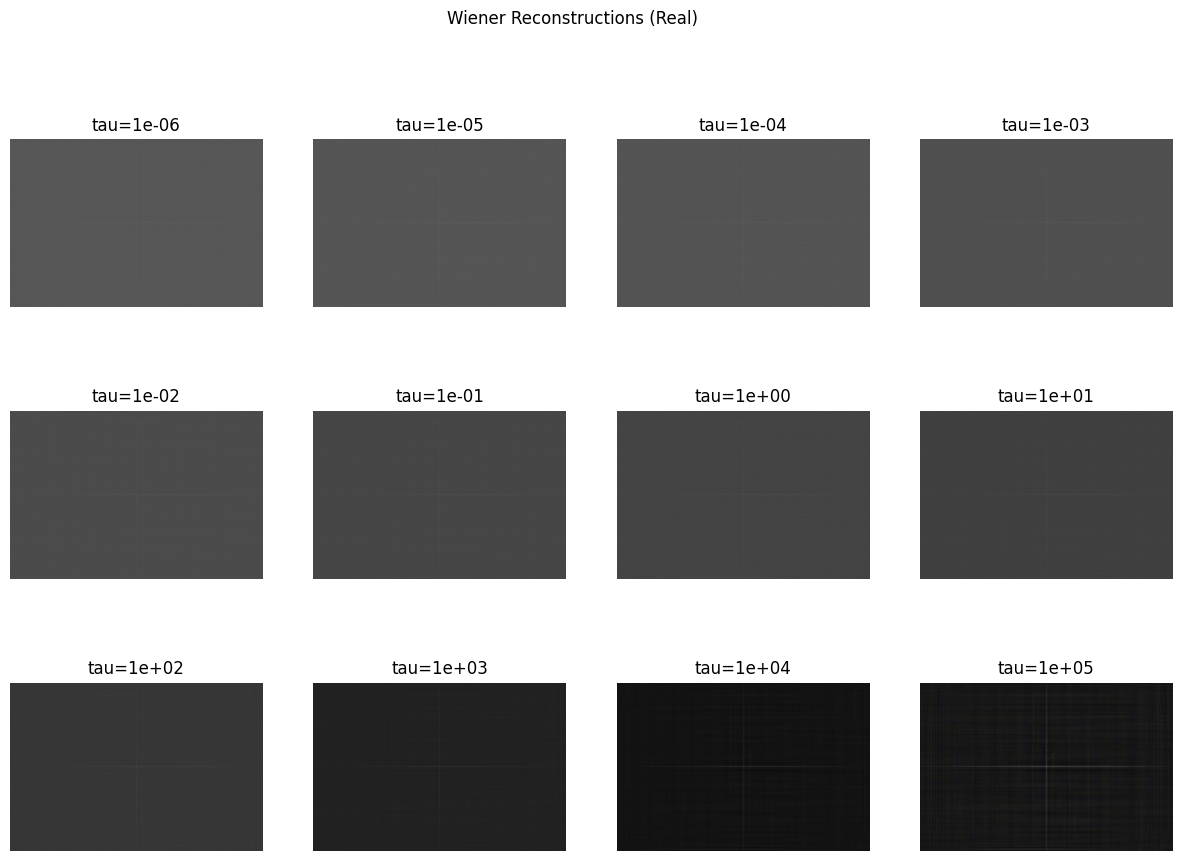

In [8]:
taus = [10**k for k in range(-6, 6)]

plt.figure(figsize=(15, 10))

for i, tau in enumerate(taus):
    recon = wiener(dif, psf, tau)

    # normalize for display
    recon = (recon - recon.min()) / (recon.max() - recon.min())

    plt.subplot(3, 4, i+1)
    plt.imshow(recon, cmap='gray')
    plt.title(f"tau={tau:.0e}")
    plt.axis('off')

plt.suptitle("Wiener Reconstructions (Real)")
plt.show()

In [ ]:
taus = [10**k for k in range(-6, 6)]

plt.figure(figsize=(15, 10))

for i, tau in enumerate(taus):
    recon = wiener(reference_result, psf, tau)

    # normalize for display
    recon = (recon - recon.min()) / (recon.max() - recon.min())

    plt.subplot(3, 4, i+1)
    plt.imshow(recon, cmap='gray')
    plt.title(f"tau={tau:.0e}")
    plt.axis('off')

plt.suptitle("Wiener Reconstructions (Synthetic)")
plt.show()